In [18]:
!pip install scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.1 MB 1.7 MB/s eta 0:00:07
   - -------------------------------------- 0.5/11.1 MB 4.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.5/11.1 MB 10.7 MB/s eta 0:00:01
   ----------------- ---------------------- 4.9/11.1 MB 26.3 MB/s eta 0:00:01
   ----------------- ---------------------- 5.0/11.1 MB 22.6 MB/s eta 0:00:01
   ------------------------------------- -- 10.4/11.1 MB 46.7 MB/s eta 0:00:01
   ---------------------------------------  11.1/11.1 MB 59.5 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 46.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/301.8 kB ? eta -:--:--
   ---------------------------------------- 301.8/301.8 kB 9.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\student\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import wrds 

In [2]:
# Connect to WRDS
conn = wrds.Connection()

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
# SQL query to get monthly stock returns from CRSP
query_crsp = """
SELECT permno, date, ret, shrout, prc
FROM crsp.msf
WHERE date >= '2010-01-01'
"""
# Run query and store data in a pandas DataFrame
crsp_data = conn.raw_sql(query_crsp, date_cols=['date'])

In [4]:
# Convert shares outstanding to billions for scaling
crsp_data['mkt_cap'] = (crsp_data['shrout'] * abs(crsp_data['prc'])) / 1e6

In [5]:
query_compustat = """
SELECT gvkey, datadate, at, seq, pstkl, txditc, csho, prcc_f,
       ni, dltt, dlc
FROM comp.funda
WHERE indfmt = 'INDL' AND datafmt = 'STD' AND popsrc = 'D' AND consol = 'C'
AND datadate >= '2010-01-01'
"""
compustat_data = conn.raw_sql(query_compustat, date_cols=['datadate'])

In [8]:
import numpy as np

# Ensure returns are numeric and replace missing values
crsp_data['ret'] = pd.to_numeric(crsp_data['ret'], errors='coerce').fillna(0)

# Sort data by stock (permno) and date
crsp_data = crsp_data.sort_values(by=['permno', 'date'])

# Compute past 12-month momentum (excluding the last month)
crsp_data['momentum'] = (
    crsp_data.groupby('permno')['ret']
    .transform(lambda x: (1 + x.shift(1)).rolling(11).apply(np.prod, raw=True) - 1)
)


In [9]:
print(crsp_data[['permno', 'date', 'ret', 'momentum']].head(20))

    permno       date       ret  momentum
0    10001 2010-01-29 -0.018932       NaN
1    10001 2010-02-26 -0.000656       NaN
2    10001 2010-03-31  0.020643       NaN
3    10001 2010-04-30  0.124385       NaN
4    10001 2010-05-28  0.004829       NaN
5    10001 2010-06-30 -0.043421       NaN
6    10001 2010-07-30  0.083333       NaN
7    10001 2010-08-31 -0.111263       NaN
8    10001 2010-09-30   0.07656       NaN
9    10001 2010-10-29  0.032815       NaN
10   10001 2010-11-30 -0.118436       NaN
11   10001 2010-12-31  0.052291  0.020624
12   10001 2011-01-31  0.028992  0.094719
13   10001 2011-02-28  0.022727  0.127196
14   10001 2011-03-31  0.072404  0.129498
15   10001 2011-04-29 -0.038789  0.077281
16   10001 2011-05-31   0.02805  0.030518
17   10001 2011-06-30  0.008261  0.107513
18   10001 2011-07-29 -0.028139  0.030765
19   10001 2011-08-31 -0.013864  0.127173


In [10]:
# Compute Book Equity (BE) for Book-to-Market Ratio
compustat_data['be'] = (compustat_data['seq'] 
                        - compustat_data['pstkl'].fillna(0) 
                        + compustat_data['txditc'].fillna(0))

# Compute Market Equity (ME)
compustat_data['me'] = compustat_data['csho'] * compustat_data['prcc_f']

# Compute Book-to-Market Ratio
compustat_data['bm'] = compustat_data['be'] / compustat_data['me']

# Compute Leverage
compustat_data['leverage'] = (compustat_data['dltt'].fillna(0) + compustat_data['dlc'].fillna(0)) / compustat_data['be']

# Compute ROE
compustat_data['roe'] = compustat_data['ni'] / compustat_data['be']

# Compute Asset Growth
compustat_data['asset_growth'] = compustat_data.groupby('gvkey')['at'].pct_change()

C:\Users\student\AppData\Local\Temp\ipykernel_6704\4217343744.py:19: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  compustat_data['asset_growth'] = compustat_data.groupby('gvkey')['at'].pct_change()


In [12]:
# Get link between CRSP and Compustat
query_link = "SELECT gvkey, lpermno AS permno FROM crsp.ccmxpf_linktable"
link_table = conn.raw_sql(query_link)

# Merge CRSP stock returns with Compustat firm characteristics
merged_data = crsp_data.merge(link_table, on='permno', how='left')
merged_data = merged_data.merge(compustat_data, on=['gvkey', 'datadate'], how='left')

KeyError: 'datadate'

In [13]:
# Ensure `datadate` is in datetime format in both datasets
compustat_data['datadate'] = pd.to_datetime(compustat_data['datadate'])
merged_data['date'] = pd.to_datetime(merged_data['date'])  # Ensure date is datetime

# Merge CRSP stock returns with the Compustat link table
merged_data = crsp_data.merge(link_table, on='permno', how='left')

# Ensure `datadate` aligns with `date`
merged_data = merged_data.merge(compustat_data, left_on=['gvkey', 'date'], right_on=['gvkey', 'datadate'], how='left')


In [14]:
import numpy as np

# Drop rows with missing key variables
merged_data.dropna(subset=['ret', 'mkt_cap', 'bm', 'momentum', 'roe', 'leverage', 'asset_growth'], inplace=True)

# Winsorization: Cap extreme values at 1st and 99th percentiles
for col in ['bm', 'roe', 'leverage', 'asset_growth']:
    p1, p99 = np.percentile(merged_data[col].dropna(), [1, 99])
    merged_data[col] = np.clip(merged_data[col], p1, p99)


In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Target variable: Next month's return (shifted by -1 to align with features)
merged_data = merged_data.sort_values(by=['permno', 'date'])
merged_data['ret_fwd'] = merged_data.groupby('permno')['ret'].shift(-1)

# Define predictor variables (X) and target variable (y)
features = ['mkt_cap', 'bm', 'momentum', 'roe', 'leverage', 'asset_growth']
X = merged_data[features]
y = merged_data['ret_fwd']


In [21]:
from sklearn.preprocessing import StandardScaler

# Drop missing target values (before defining X)
merged_data = merged_data.dropna(subset=['ret_fwd'])

# Define predictor variables AFTER dropping NaN values in y
features = ['mkt_cap', 'bm', 'momentum', 'roe', 'leverage', 'asset_growth']
X = merged_data[features]
y = merged_data['ret_fwd']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # No index mismatch here

# Convert scaled values back to DataFrame
X = pd.DataFrame(X_scaled, columns=features, index=merged_data.index)


In [22]:
print(X.shape, y.shape)


(38712, 6) (38712,)


In [24]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# Define model parameters
alphas = np.logspace(-4, 2, 5)  # Reduce number of lambda values for speed

# Lists to store results
ridge_results, lasso_results, ols_results = [], [], []

# Sort data by time
merged_data = merged_data.sort_values(by=['date'])

# Expanding window setup
split_ratio = 0.7  # Use 70% of the data initially, then expand
n_obs = len(merged_data)
split = int(split_ratio * n_obs)

# Initialize models once to avoid repeated object creation
ols = LinearRegression()

for i in range(split, n_obs, 10):  # Step size of 10 to speed up iteration
    # Use all data up to the i-th row for training
    X_train, y_train = X.iloc[:i], y.iloc[:i]
    X_test, y_test = X.iloc[i:i+10], y.iloc[i:i+10]  # Test on the next 10 periods at once

    # Fit OLS
    ols.fit(X_train, y_train)
    ols_pred = ols.predict(X_test)
    ols_results.append(r2_score(y_test, ols_pred))

    best_ridge_r2, best_lasso_r2 = -np.inf, -np.inf

    for alpha in alphas:
        # Fit Ridge
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, y_train)
        ridge_pred = ridge.predict(X_test)
        ridge_r2 = r2_score(y_test, ridge_pred)

        if ridge_r2 > best_ridge_r2:
            best_ridge_r2 = ridge_r2

        # Fit Lasso
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_train, y_train)
        lasso_pred = lasso.predict(X_test)
        lasso_r2 = r2_score(y_test, lasso_pred)

        if lasso_r2 > best_lasso_r2:
            best_lasso_r2 = lasso_r2

    ridge_results.append(best_ridge_r2)
    lasso_results.append(best_lasso_r2)

# Convert results into DataFrame
results_df = pd.DataFrame({
    'OLS_R2': ols_results,
    'Ridge_R2': ridge_results,
    'Lasso_R2': lasso_results
})


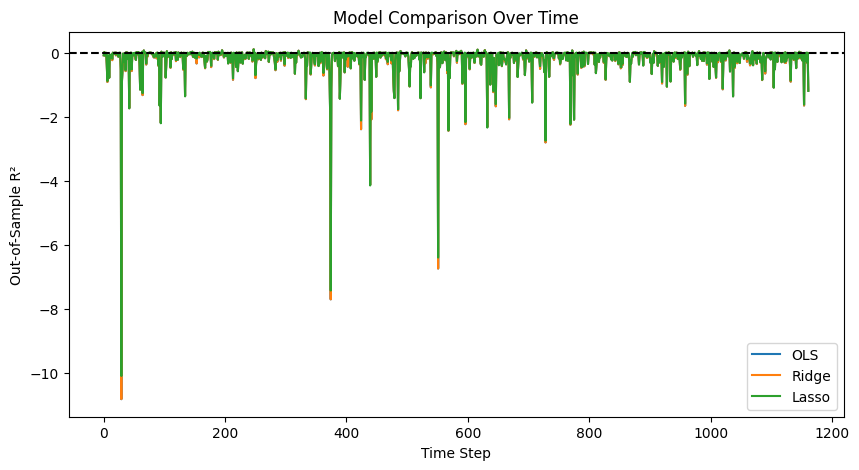

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_df['OLS_R2'], label='OLS')
plt.plot(results_df['Ridge_R2'], label='Ridge')
plt.plot(results_df['Lasso_R2'], label='Lasso')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Out-of-Sample R²')
plt.title('Model Comparison Over Time')
plt.legend()
plt.show()


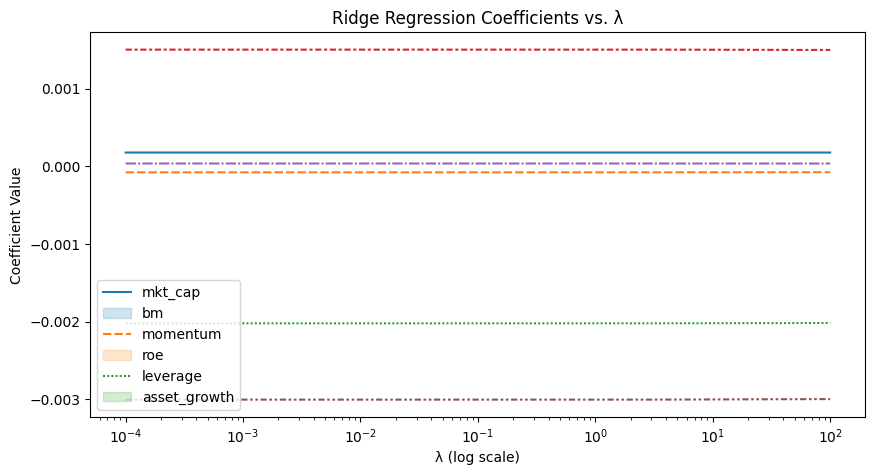

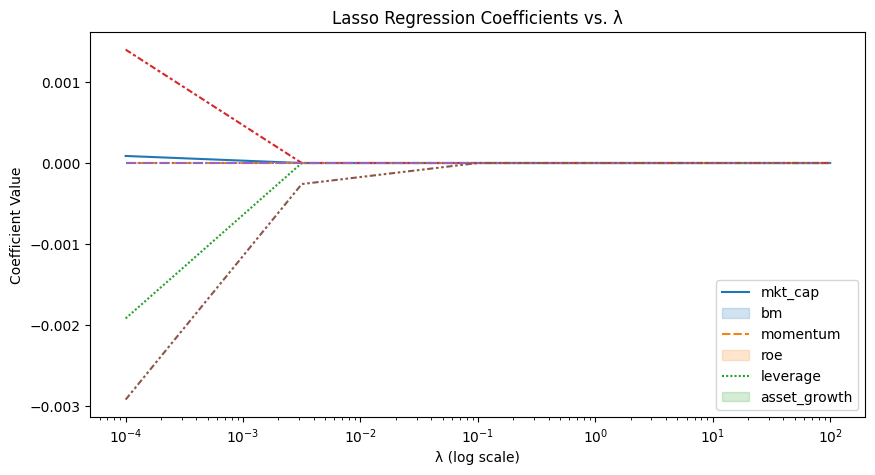

In [26]:
import seaborn as sns

ridge_coefs, lasso_coefs = [], []

# Train Ridge & Lasso for different λ values
for alpha in alphas:
    ridge = Ridge(alpha=alpha).fit(X, y)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha).fit(X, y)
    lasso_coefs.append(lasso.coef_)

# Convert to DataFrame for visualization
ridge_coefs_df = pd.DataFrame(ridge_coefs, columns=features, index=alphas)
lasso_coefs_df = pd.DataFrame(lasso_coefs, columns=features, index=alphas)

# Plot Ridge coefficients
plt.figure(figsize=(10, 5))
sns.lineplot(data=ridge_coefs_df)
plt.xscale("log")
plt.title("Ridge Regression Coefficients vs. λ")
plt.xlabel("λ (log scale)")
plt.ylabel("Coefficient Value")
plt.legend(features)
plt.show()

# Plot Lasso coefficients
plt.figure(figsize=(10, 5))
sns.lineplot(data=lasso_coefs_df)
plt.xscale("log")
plt.title("Lasso Regression Coefficients vs. λ")
plt.xlabel("λ (log scale)")
plt.ylabel("Coefficient Value")
plt.legend(features)
plt.show()


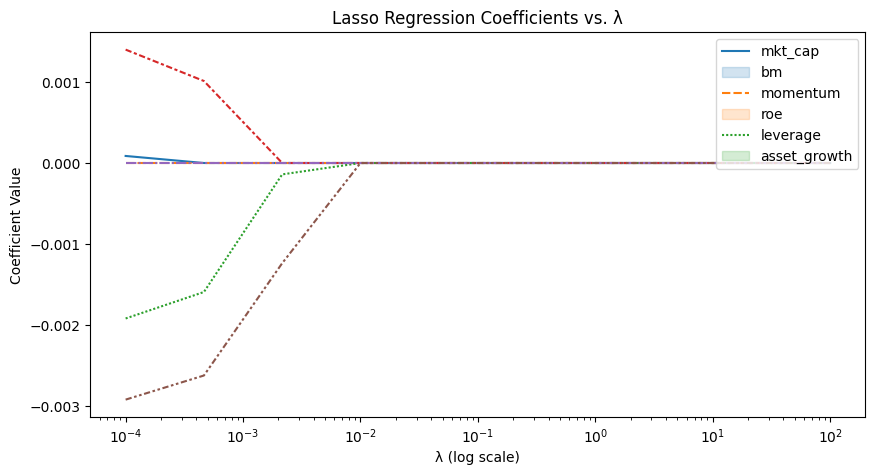

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import Lasso

alphas = np.logspace(-4, 2, 10)  # Range of λ values
lasso_coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    lasso_coefs.append(lasso.coef_)

# Convert to DataFrame for visualization
lasso_coefs_df = pd.DataFrame(lasso_coefs, columns=X.columns, index=alphas)

# Plot Lasso coefficients
plt.figure(figsize=(10, 5))
sns.lineplot(data=lasso_coefs_df)
plt.xscale("log")  # Log scale for better visualization
plt.xlabel("λ (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients vs. λ")
plt.legend(X.columns, loc='upper right')
plt.show()


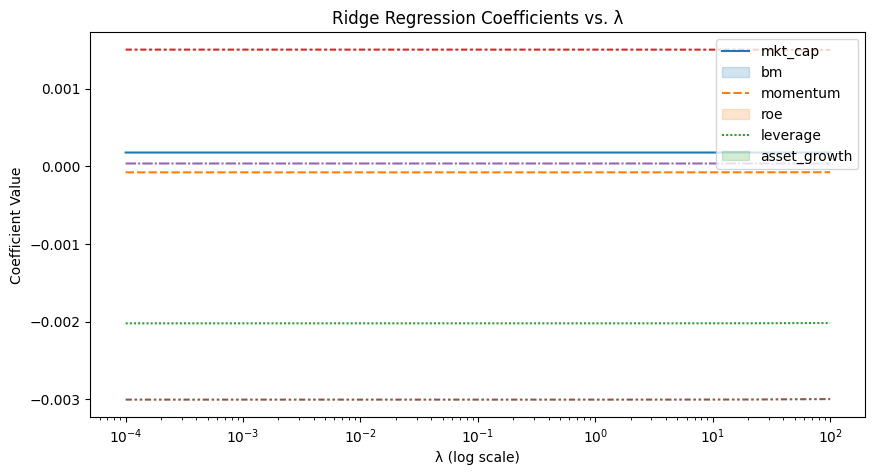

OLS Coefficients:
 [ 1.76493067e-04 -7.86069134e-05 -2.02260405e-03  1.50135072e-03
  3.53037475e-05 -3.00468892e-03]

Ridge Coefficients (moderate λ):
 mkt_cap         0.000176
bm             -0.000079
momentum       -0.002023
roe             0.001501
leverage        0.000035
asset_growth   -0.003005
Name: 0.21544346900318823, dtype: float64


In [28]:
from sklearn.linear_model import Ridge, LinearRegression

ridge_coefs = []
ols = LinearRegression()
ols.fit(X, y)
ols_coefs = ols.coef_

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    ridge_coefs.append(ridge.coef_)

# Convert to DataFrame for visualization
ridge_coefs_df = pd.DataFrame(ridge_coefs, columns=X.columns, index=alphas)

# Plot Ridge coefficients
plt.figure(figsize=(10, 5))
sns.lineplot(data=ridge_coefs_df)
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression Coefficients vs. λ")
plt.legend(X.columns, loc='upper right')
plt.show()

# Print OLS vs Ridge coefficients at a selected λ
print("OLS Coefficients:\n", ols_coefs)
print("\nRidge Coefficients (moderate λ):\n", ridge_coefs_df.iloc[5])  # Pick mid-range λ


In [29]:
# Compute rolling volatility (30-day std dev of market returns)
merged_data['market_volatility'] = merged_data.groupby('date')['ret'].transform(lambda x: x.rolling(30).std())

# Define high-volatility periods (top 20% percentile)
vol_threshold = merged_data['market_volatility'].quantile(0.8)
merged_data['high_volatility'] = (merged_data['market_volatility'] > vol_threshold).astype(int)


In [32]:
# Ensure dates are sorted and unique in merged_data
unique_dates = merged_data['date'].sort_values().unique()

# Ensure that results_df and unique_dates have the same length
if len(results_df) > len(unique_dates):
    results_df = results_df.iloc[:len(unique_dates)]
elif len(unique_dates) > len(results_df):
    unique_dates = unique_dates[:len(results_df)]

# Assign correct dates to results_df
results_df['date'] = unique_dates

# Merge volatility data with results_df
volatility_df = merged_data[['date', 'market_volatility', 'high_volatility']].drop_duplicates()
results_df = results_df.merge(volatility_df, on='date', how='left')

# Compute average R² scores for high and low volatility periods
high_vol_r2 = results_df[results_df['high_volatility'] == 1].mean(numeric_only=True)
low_vol_r2 = results_df[results_df['high_volatility'] == 0].mean(numeric_only=True)

# Print comparison
print("Model Performance in High vs. Low Volatility Periods:")
print("\nHigh Volatility R² Scores:\n", high_vol_r2)
print("\nLow Volatility R² Scores:\n", low_vol_r2)


Model Performance in High vs. Low Volatility Periods:

High Volatility R² Scores:
 OLS_R2              -0.039808
Ridge_R2            -0.039759
Lasso_R2            -0.030922
market_volatility    0.243345
high_volatility      1.000000
dtype: float64

Low Volatility R² Scores:
 OLS_R2              -0.166090
Ridge_R2            -0.166000
Lasso_R2            -0.145379
market_volatility    0.103285
high_volatility      0.000000
dtype: float64


C:\Users\student\AppData\Local\Temp\ipykernel_6704\1176414186.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['date'] = unique_dates
